In [1]:
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, FastICA, NMF, FactorAnalysis
from sklearn.manifold import LocallyLinearEmbedding
import deep_sdf.workspace as ws
from sdf_utils import sap
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
import time

In [2]:
# 1. Load the latent vectors from your trained model
experiment_dir = "/home/jakaria/INR/Deep3DComp/examples/torus/sixteen_variable_z" 
checkpoint = "latest" 

# Load latent vectors
latent_vectors = ws.load_latent_vectors(experiment_dir, checkpoint)
X = latent_vectors.cpu().numpy()

print(f"Loaded latent vectors with shape: {X.shape}")

Loaded latent vectors with shape: (369, 16)


In [4]:
# 2. Load the filenames of the meshes
with open(os.path.join(experiment_dir, "specs.json"), "r") as f:
    import json
    specs = json.load(f)
# Load all labels from the centralized label.pt file
data_source = specs["DataSource"]
data_source_mesh = specs["DataSourceMesh"]
train_split_file = specs["TrainSplit"]
labels_path = os.path.join(data_source, "labels.pt")

# Load the split file to get filenames
with open(train_split_file, "r") as f:
    valid_filenames = json.load(f)

if os.path.exists(labels_path):
    print(f"Loading labels from {labels_path}")
    all_labels = torch.load(labels_path)
    print(f"All labels: {all_labels}")
    
    # Extract parameters for each filename
    mesh_params = []
    for filename in valid_filenames:
        # Extract base name without extension to match with label dict key
        base_name = os.path.splitext(os.path.basename(filename))[0]
        print(f"Base name: {base_name}")
        params = {}
        if base_name in all_labels:
            label = all_labels[base_name]
            params["has_bump"] = int(label[0].item())  # bump info at index 0
            params["scale"] = float(label[2].item())   # scale info at index 2
            #print(f"Label for {base_name}: {params}")
        else:
            print(f"Warning: No label found for {base_name}")
            params["has_bump"] = 0
            params["scale"] = 0.0
        
        mesh_params.append(params)

Loading labels from /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle/sdf_data/SdfSamples/scaled_obj_files/labels.pt
All labels: {'torus_bump_0000': array([0.        , 1.        , 0.46153846, 0.08361204]), 'torus_bump_0001': array([1.        , 1.        , 0.8361204 , 0.64548495]), 'torus_bump_0002': array([0.        , 1.        , 0.96655518, 0.0735786 ]), 'torus_bump_0003': array([1.        , 1.        , 0.98327759, 0.26421405]), 'torus_bump_0004': array([0.        , 1.        , 0.66889632, 0.48494983]), 'torus_bump_0005': array([1.        , 1.        , 0.92976589, 0.54849498]), 'torus_bump_0006': array([0.        , 1.        , 0.85284281, 0.52508361]), 'torus_bump_0007': array([1.        , 1.        , 0.84949833, 0.73578595]), 'torus_bump_0008': array([0.        , 1.        , 0.04682274, 0.17391304]), 'torus_bump_0009': array([1.        , 1.        , 0.56187291, 0.7993311 ]), 'torus_bump_0010': array([0.        , 1.        , 0.62207358, 0.89297659]), 'toru

In [5]:
# Extract parameters for visualization
has_bump = np.array([p.get("has_bump", 0) for p in mesh_params])
scales = np.array([p.get("scale", 0.0) for p in mesh_params])

# Create ground truth factors array for SAP calculation
ground_truth_factors = np.column_stack((has_bump, scales))
factor_names = ["bump", "scale"]

In [6]:
# 3. Apply various dimensionality reduction and factor analysis techniques
plt.figure(figsize=(20, 16))
results = {}
transformed_latents = {}
distances_all = []


<Figure size 2000x1600 with 0 Axes>

In [18]:

# 3.1. PCA
print("Applying PCA...")
pca = PCA(n_components=2)
Y_pca = pca.fit_transform(X)
results["PCA"] = Y_pca
transformed_latents["PCA"] = Y_pca
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")

# check if the scale is encoded as distance from the origin
center = np.mean(Y_pca, axis=0)
distances = np.sqrt(np.sum((Y_pca - center) ** 2, axis=1))
# check correlation between distance and scale
print(f"Correlation between distance from origin and scale: {np.corrcoef(distances, scales)[0, 1]:.4f}")
distances_pca = distances
distances_all.append(distances)

# 3.2. HLLE+ICA

best_corr = -np.inf
best_Y_hlle_ica = None
best_params = None

# Loop over a range of n_neighbors and latent space dimensions (2 to 4)
for n_neighbors in range(300, 320, 10):  # e.g., 5, 10, 15, 20, 25 neighbors
    for n_components in [2]:
        try:
            # Apply HLLE with current parameter set
            hlle = LocallyLinearEmbedding(n_neighbors=n_neighbors,
                                           n_components=n_components,
                                           method='hessian',
                                           eigen_solver='dense')
            Z = hlle.fit_transform(X)

            # Apply ICA to the HLLE result
            ica = FastICA(n_components=n_components, random_state=42)
            Y_hlle_ica = ica.fit_transform(Z)

            # Compute the correlation for each latent variable with scales
            correlations = []
            for comp in range(n_components):
                corr = np.corrcoef(Y_hlle_ica[:, comp], has_bump)[0, 1]
                correlations.append(corr)
            print(correlations)
            # Find the index of the component with the highest absolute correlation
            best_component_idx = max(range(n_components), key=lambda i: abs(correlations[i]))
            best_component_corr = correlations[best_component_idx]
            
            # Print the results
            print(f"n_neighbors: {n_neighbors}, n_components: {n_components}, "
                  f"best component correlation: {best_component_corr:.4f}")

            # Update if this parameter set shows a higher absolute correlation than previous sets
            if abs(best_component_corr) > best_corr:
                best_corr = best_component_corr
                best_Y_hlle_ica = Y_hlle_ica
                best_params = (n_neighbors, n_components, best_component_idx)
                
        except Exception as e:
            print(f"Failed for n_neighbors: {n_neighbors}, n_components: {n_components} due to: {e}")

if best_Y_hlle_ica is not None:
    print("\nBest parameter set:")
    print(f"n_neighbors: {best_params[0]}, n_components: {best_params[1]}, best component: {best_params[2]} best correlation: {best_corr:.4f}")
    results["HLLE+ICA"] = best_Y_hlle_ica
    transformed_latents["HLLE+ICA"] = best_Y_hlle_ica
else:
    print("No valid HLLE+ICA transformation found.")

Applying PCA...
PCA explained variance ratio: 0.1704
Correlation between distance from origin and scale: -0.0790
[0.9246336691793327, 0.07212083847187409]
n_neighbors: 300, n_components: 2, best component correlation: 0.9246
[-0.05529929753395482, 0.9249144437740663]
n_neighbors: 310, n_components: 2, best component correlation: 0.9249

Best parameter set:
n_neighbors: 310, n_components: 2, best component: 1 best correlation: 0.9249


In [19]:
# 3.3. NMF
print("Applying NMF...")
# NMF requires non-negative values
X_min = X.min()
if X_min < 0:
    X_offset = X - X_min  # Shift data to make all values non-negative
else:
    X_offset = X.copy()

best_corr_nmf = None
best_W_nmf = None
best_nmf_params = None

# Loop over latent dimensions 2, 3, and 4
for n_components in [2, 3, 4]:
    try:
        nmf = NMF(n_components=n_components, random_state=42, max_iter=10000)
        # W is the latent representation: shape (num_samples, n_components)
        W = nmf.fit_transform(X_offset)
        
        # Compute the Pearson correlation for each latent component with the scale
        correlations = []
        for comp in range(n_components):
            corr = np.corrcoef(W[:, comp], has_bump)[0, 1]
            correlations.append(corr)
        
        # Identify the best component correlation (by absolute value)
        best_component_corr = max(correlations, key=abs)
        print(f"n_components: {n_components}, best component correlation: {best_component_corr:.4f}")

        # Update if this parameter set shows a higher absolute correlation than previous sets
        if best_corr_nmf is None or abs(best_component_corr) > best_corr_nmf:
            best_corr_nmf = best_component_corr
            best_W_nmf = W
            best_nmf_params = n_components
            
    except Exception as e:
        print(f"Failed for n_components: {n_components} due to: {e}")

if best_W_nmf is not None:
    print("\nBest NMF parameter set:")
    print(f"n_components: {best_nmf_params}, best correlation: {best_corr_nmf:.4f}")
    results["NMF"] = best_W_nmf
    transformed_latents["NMF"] = best_W_nmf
else:
    print("No valid NMF transformation found.")

Applying NMF...
n_components: 2, best component correlation: 0.8979
n_components: 3, best component correlation: -0.8870
n_components: 4, best component correlation: 0.8181

Best NMF parameter set:
n_components: 2, best correlation: 0.8979


In [20]:
# 3.4. Factor Analysis
print("Applying Factor Analysis...")
fa = FactorAnalysis(n_components=2, random_state=42)
Y_fa = fa.fit_transform(X)
results["FA"] = Y_fa
transformed_latents["FA"] = Y_fa

# check if the scale is encoded as distance from the origin
center = np.mean(Y_fa, axis=0)
distances = np.sqrt(np.sum((Y_fa - center) ** 2, axis=1))
# check correlation between distance and scale
print(f"Correlation between distance from origin and scale: {np.corrcoef(distances, scales)[0, 1]:.4f}")
distances_Y_fa = distances
distances_all.append(distances)

Applying Factor Analysis...
Correlation between distance from origin and scale: -0.1161


In [21]:
# only ica
# 3.5. ICA
print("Applying ICA...")
ica = FastICA(n_components=2, random_state=42)
Y_ica = ica.fit_transform(X)
results["ICA"] = Y_ica
transformed_latents["ICA"] = Y_ica

# check if the scale is encoded as distance from the origin
center = np.mean(Y_ica, axis=0)
distances = np.sqrt(np.sum((Y_ica - center) ** 2, axis=1))
# check correlation between distance and scale
print(f"Correlation between distance from origin and scale: {np.corrcoef(distances, scales)[0, 1]:.4f}")
distances_Y_ica = distances
distances_all.append(distances)

Applying ICA...
Correlation between distance from origin and scale: -0.0722


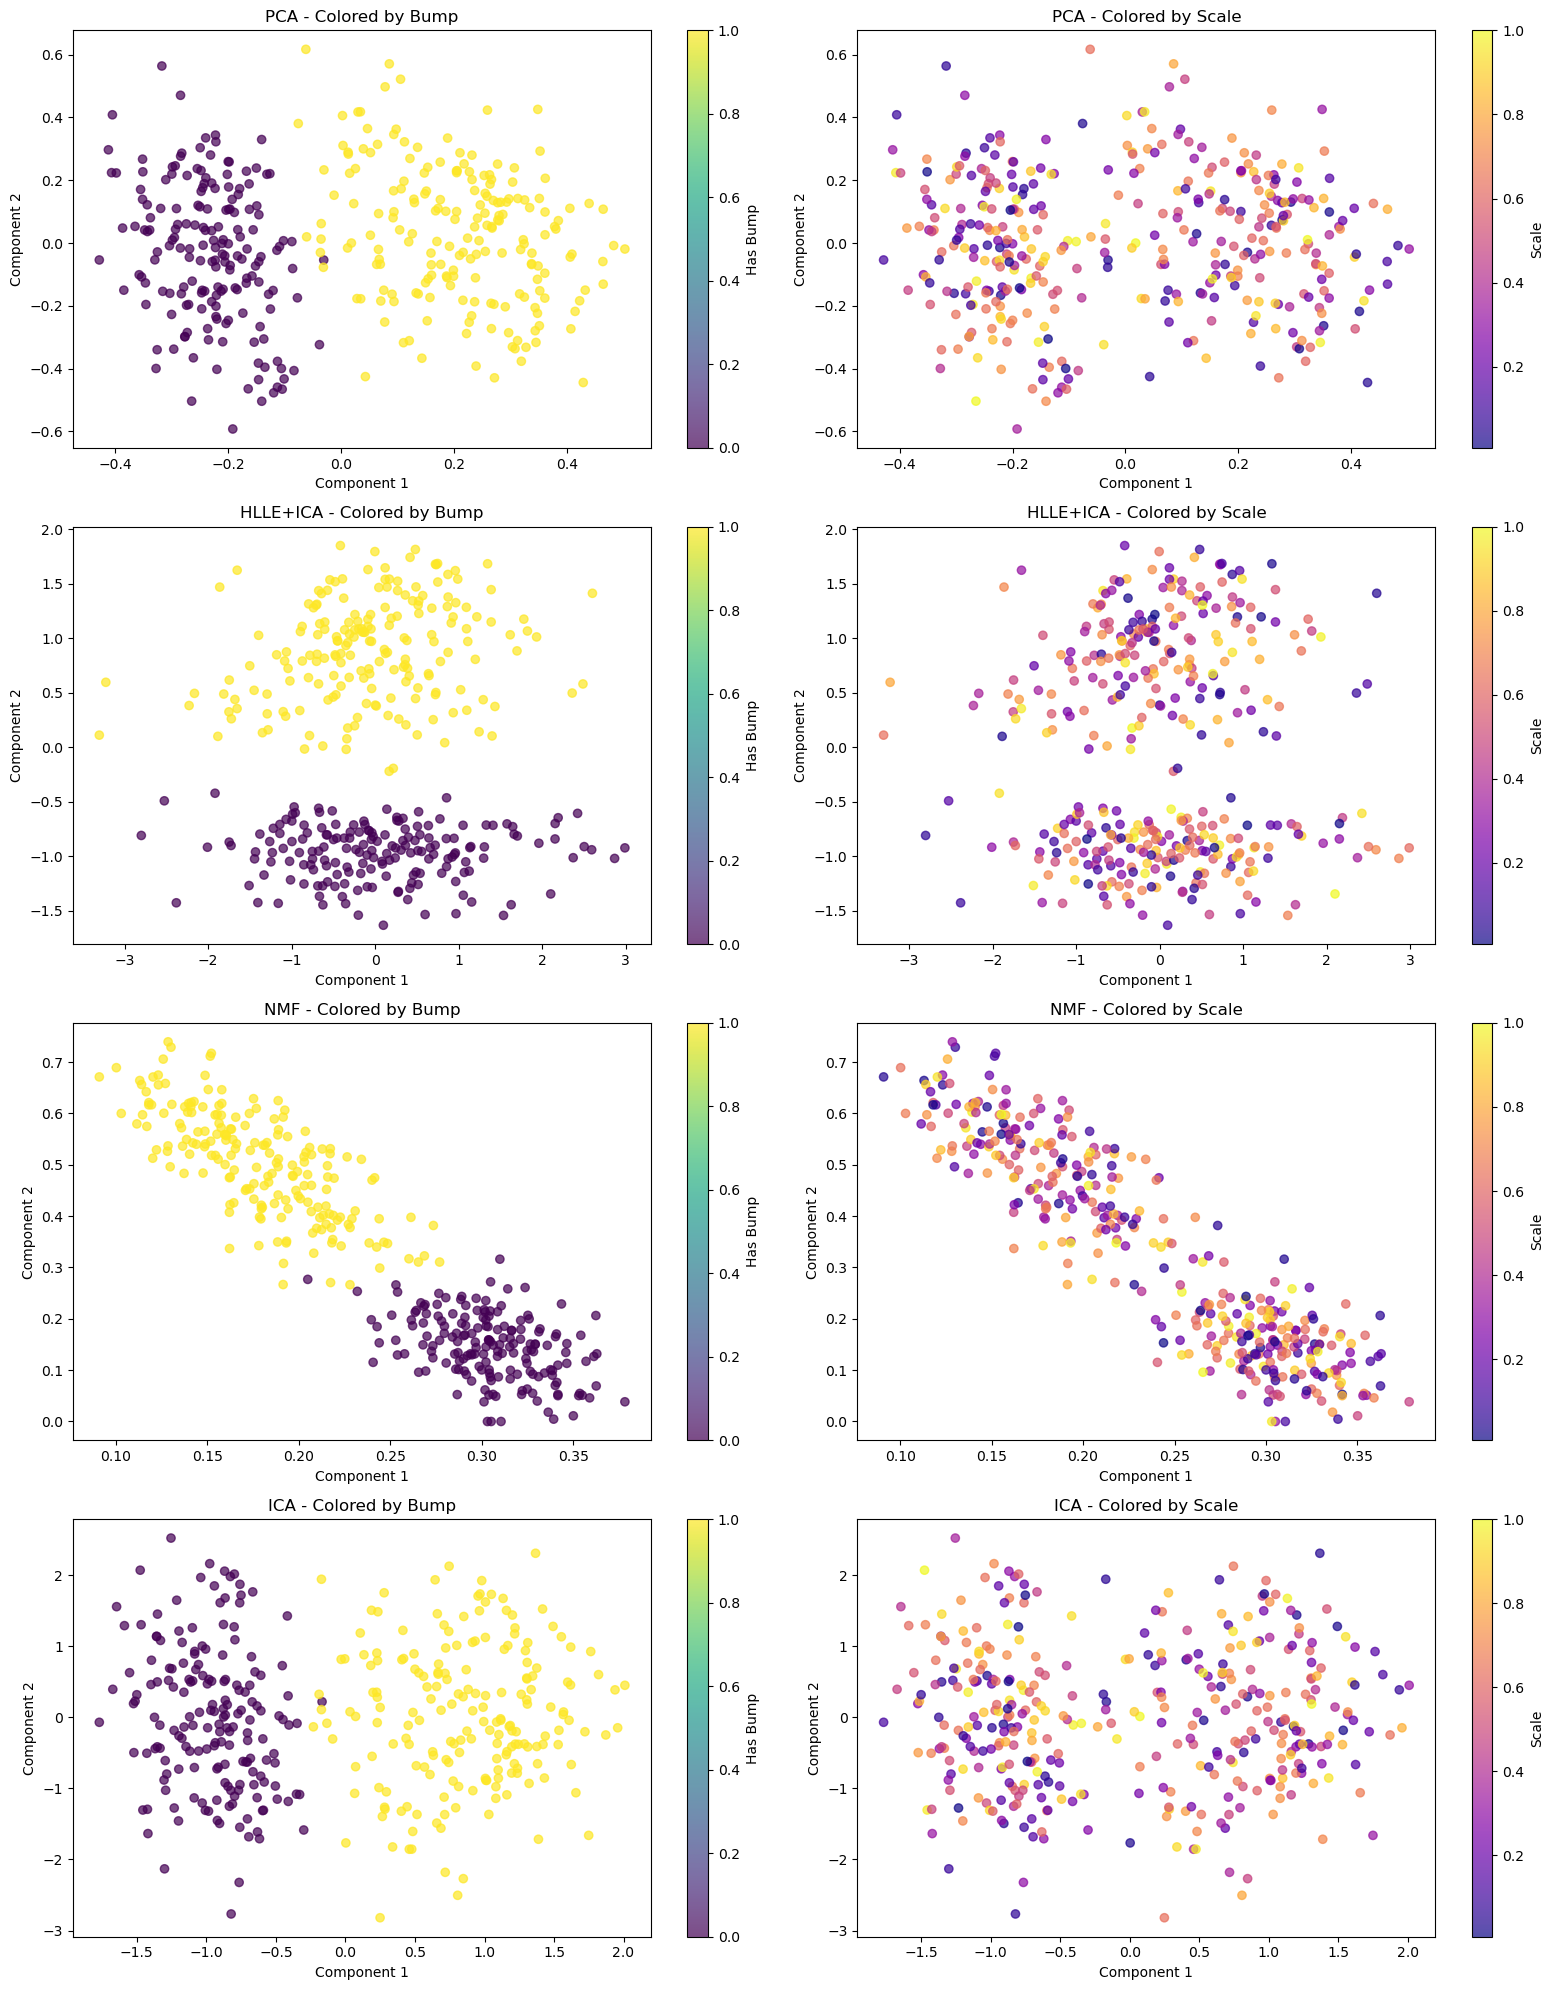

In [25]:
# 4. Visualize results
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

# Plot each technique with bump and scale coloring
techniques = ["PCA", "HLLE+ICA", "NMF", "ICA"]
for i, technique in enumerate(techniques):
    # Skip if the method failed
    if np.all(results[technique] == 0):
        continue
        
    # Plot colored by bump
    scatter = axes[i, 0].scatter(results[technique][:, 0], results[technique][:, 1], 
                                c=has_bump, cmap='viridis', alpha=0.7)
    axes[i, 0].set_title(f"{technique} - Colored by Bump")
    axes[i, 0].set_xlabel("Component 1")
    axes[i, 0].set_ylabel("Component 2")
    
    plt.colorbar(scatter, ax=axes[i, 0], label="Has Bump")

    
    # Plot colored by scale
    scatter = axes[i, 1].scatter(results[technique][:, 0], results[technique][:, 1], 
                                c=scales, cmap='plasma', alpha=0.7)
    axes[i, 1].set_title(f"{technique} - Colored by Scale")
    axes[i, 1].set_xlabel("Component 1")
    axes[i, 1].set_ylabel("Component 2")
    plt.colorbar(scatter, ax=axes[i, 1], label="Scale")

plt.tight_layout()
plt.savefig("latent_space_analysis.png", dpi=300)
plt.show()


In [23]:
# 5. Correlation Analysis
print("\nCorrelation Analysis:")
for technique in techniques:
    # Skip if the method failed
    if np.all(results[technique] == 0):
        continue
        
    bump_corr_1 = np.corrcoef(results[technique][:, 0], has_bump)[0, 1]
    bump_corr_2 = np.corrcoef(results[technique][:, 1], has_bump)[0, 1]
    scale_corr_1 = np.corrcoef(results[technique][:, 0], scales)[0, 1]
    scale_corr_2 = np.corrcoef(results[technique][:, 1], scales)[0, 1]
    
    print(f"\n{technique} Analysis:")
    print(f"Component 1 correlation with bump: {bump_corr_1:.4f}")
    print(f"Component 2 correlation with bump: {bump_corr_2:.4f}")
    print(f"Component 1 correlation with scale: {scale_corr_1:.4f}")
    print(f"Component 2 correlation with scale: {scale_corr_2:.4f}")




Correlation Analysis:

PCA Analysis:
Component 1 correlation with bump: 0.8973
Component 2 correlation with bump: 0.1444
Component 1 correlation with scale: -0.0074
Component 2 correlation with scale: -0.0395

HLLE+ICA Analysis:
Component 1 correlation with bump: -0.0553
Component 2 correlation with bump: 0.9249
Component 1 correlation with scale: 0.0249
Component 2 correlation with scale: -0.0111

NMF Analysis:
Component 1 correlation with bump: -0.8769
Component 2 correlation with bump: 0.8979
Component 1 correlation with scale: -0.0225
Component 2 correlation with scale: -0.0107

FA Analysis:
Component 1 correlation with bump: 0.8770
Component 2 correlation with bump: 0.1395
Component 1 correlation with scale: 0.0054
Component 2 correlation with scale: -0.0086

ICA Analysis:
Component 1 correlation with bump: 0.9087
Component 2 correlation with bump: 0.0173
Component 1 correlation with scale: -0.0143
Component 2 correlation with scale: 0.0376
